# Baseline Models

In [ ]:
import logging
import os
from pathlib import Path
from dotenv import load_dotenv

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle

from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
import shap

from aml.pipelines.feature_pipeline import FeaturePipeline
from aml.models.build_model import AMLEnsemble
from aml.evaluating.time_split import chronological_split, describe_split
from aml.evaluating.metrics import evaluate_binary_classifier, find_best_threshold
from aml.persistence import save_aml_ensemble, save_base_models_only

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

## Testing on a small amount of data

Load only 500 000 rows for feature selection

In [5]:
load_dotenv("../.env")
DATA_PATH = Path(os.getenv("DATA_PATH", "data")).expanduser()
CSV_PATH = DATA_PATH / "raw/AMLNet_August_2025.csv"
ROW_LIMIT = 500000
TARGET_COL = "isFraud"
SPLIT_CFG = dict(test_days=20, val_days=15, gap_days=1)
RANDOM_STATE = 42

In [ ]:
raw_df = pd.read_csv(CSV_PATH, nrows=ROW_LIMIT)
target = raw_df[TARGET_COL]
raw_df = FeaturePipeline(enable_columns=True, enable_encoding=False).fit_transform(raw_df, target)
raw_df[TARGET_COL] = target

print(f"Shape: {raw_df.shape}")
print(raw_df[[TARGET_COL]].describe())
print(f"Positive rate: {raw_df[TARGET_COL].mean():.6f}")

In [ ]:
split = chronological_split(raw_df, timestamp_col="timestamp_ts", **SPLIT_CFG)
stats = describe_split(split, target=TARGET_COL)
print(stats)

train_df = split.train.sort_values("timestamp_ts").reset_index(drop=True)
val_df = split.val.sort_values("timestamp_ts").reset_index(drop=True)
test_df = split.test.sort_values("timestamp_ts").reset_index(drop=True)

print({k: v.shape for k, v in {" val": train_df, "val": val_df, "test": test_df}.items()})

{'train_n': 371905, 'train_pos': 538, 'train_pos_rate': 0.0014466059880883558, 'val_n': 84075, 'val_pos': 73, 'val_pos_rate': 0.0008682723758548915, 'test_n': 28286, 'test_pos': 108, 'test_pos_rate': 0.003818143251078272}
{' val': (371905, 39), 'val': (84075, 39), 'test': (28286, 39)}


In [ ]:
pipe = FeaturePipeline(enable_encoding=True, enable_columns=True, alpha=20, use_logit=True)

X_train = pipe.fit_transform(train_df, train_df[TARGET_COL])
X_val = pipe.transform(val_df)
X_test = pipe.transform(test_df)

y_train = train_df[TARGET_COL].to_numpy()
y_val = val_df[TARGET_COL].to_numpy()
y_test = test_df[TARGET_COL].to_numpy()

print("Shapes | train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print(f"Train positive rate: {y_train.mean():.6f}")

2026-03-23 21:14:25,697 | INFO | FeaturePipeline initialized | downcasting=True | encoding=True | _scale=False | columns=True
2026-03-23 21:14:25,698 | INFO | ▶ fit_transform | in_shape=(371905, 39)
2026-03-23 21:14:25,698 | INFO | Input validated | shape=(371905, 39)
2026-03-23 21:14:25,698 | INFO | ▶ build_features | in_shape=(371905, 39)
2026-03-23 21:14:25,704 | WARNING | Dropping potential leakage columns: ['isFraud']
2026-03-23 21:14:25,905 | INFO | ▶ feature_engineering | in_shape=(371905, 38)
2026-03-23 21:14:25,913 | INFO | ✓ feature_engineering | out_shape=(371905, 38) | 0.008s
2026-03-23 21:14:25,913 | INFO | ▶ finalize | in_shape=(371905, 38)
2026-03-23 21:14:25,995 | INFO | ✓ finalize | out_shape=(371905, 38) | 0.082s
2026-03-23 21:14:25,998 | INFO | ✓ build_features | out_shape=(371905, 38) | 0.299s
2026-03-23 21:14:25,998 | INFO | ▶ fit_encoder | in_shape=(371905, 38)
2026-03-23 21:14:31,429 | WARNING | get_feature_names_out() exists but failed, fallback to manual build


Shapes | train/val/test: (371905, 69) (84075, 69) (28286, 69)
Train positive rate: 0.001447


## Test Leave One Out encoder

In [10]:
N_pos = (y_train == 1).sum()
N_neg = (y_train == 0).sum()

scale_pos_weight = N_neg / N_pos

In [8]:
X_train_not_encoded = train_df.drop(columns="isFraud")
y_train_not_encoded = train_df.isFraud

X_val_not_encoded = val_df.drop(columns="isFraud")
y_val_not_encoded = val_df.isFraud

X_test_not_encoded = test_df.drop(columns="isFraud")
y_test_not_encoded = test_df.isFraud

In [9]:
cat = CatBoostClassifier(
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=200,
    random_state=42,
    verbose=100,
    has_time=True
)

print("START FITTING")

result = []

cat.fit(X_train_not_encoded, y_train_not_encoded,
        eval_set=(X_val_not_encoded, y_val_not_encoded),
        cat_features=np.array(train_df.columns[(train_df.dtypes=="category") | (train_df.dtypes=="object")]),
)
metrics = evaluate_binary_classifier(cat, X_test_not_encoded, y_test_not_encoded, threshold=0.5)

result.append({
    "model": "no_encoding",
    "roc_auc": metrics["roc_auc"],
    "pr_auc": metrics["pr_auc"],
    "f1_05": metrics["f1"],
})
print("no_encoder ended with")

cat.fit(X_train, y_train,
        eval_set=(X_val, y_val),
)
metrics = evaluate_binary_classifier(cat, X_test, y_test, threshold=0.5)

result.append({
    "model": "encoding",
    "roc_auc": metrics["roc_auc"],
    "pr_auc": metrics["pr_auc"],
    "f1_05": metrics["f1"],
})
print("encoder ended with")

pd.DataFrame(result).sort_values(by="pr_auc", ascending=False)

START FITTING
Learning rate set to 0.094689
0:	test: 0.9644025	best: 0.9644025 (0)	total: 100ms	remaining: 1m 40s
100:	test: 0.9999993	best: 0.9999993 (25)	total: 3.61s	remaining: 32.1s
200:	test: 0.9999997	best: 0.9999997 (151)	total: 7.08s	remaining: 28.1s
300:	test: 0.9999997	best: 0.9999997 (151)	total: 10.8s	remaining: 25s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9999996738
bestIteration = 151

Shrink model to first 152 iterations.
no_encoder ended with
Learning rate set to 0.094689
0:	test: 0.9898920	best: 0.9898920 (0)	total: 7.23ms	remaining: 7.23s
100:	test: 1.0000000	best: 1.0000000 (44)	total: 628ms	remaining: 5.59s
200:	test: 1.0000000	best: 1.0000000 (44)	total: 1.13s	remaining: 4.48s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 44

Shrink model to first 45 iterations.
encoder ended with


,model,roc_auc,pr_auc,f1_05
0,no_encoding,0.995421,0.926585,0.900990
1,encoding,0.996115,0.921098,0.823529


## Fitting baseline models

In [9]:
base_models = {
    "xg": XGBClassifier(
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        early_stopping_rounds=200,
        random_state=42,
        use_label_encoder=False,
        verbosity=0
    ),
    "cat": CatBoostClassifier(
        eval_metric="PRAUC",
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=200,
        random_state=42,
        has_time=True,
        verbose=False
    ),
    "ligh": LGBMClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ),
}

In [10]:
result = []
feature_importances = {}
fi_perm = {}
shap_df = {}

for name, model in base_models.items():
    print("Fitting", name)
    fit_params = {
        "X": X_train,
        "y": y_train,
        "eval_set": [(X_val, y_val)]
    }
    if name == "xg":
        fit_params["verbose"] = False
    model.fit(**fit_params)

    # Basic metrics
    metrics = evaluate_binary_classifier(model, X_test, y_test, threshold=0.5)

    result.append({
        "model": name,
        "roc_auc": metrics["roc_auc"],
        "recall_curve": metrics["recall_curve"],
        "pr_auc": metrics["pr_auc"],
        "f1_05": metrics["f1"],
    })

    # Feature importance
    if name == "cat":
        fi = model.get_feature_importance()
    else:
        fi = model.feature_importances_

    feature_importances[name] = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": fi
        })
        .sort_values(by="importance", ascending=False)
        .reset_index(drop=True)
    )

    # Permutation importance 
    r = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    fi_perm[name] = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": r.importances_mean
        })
        .sort_values(by="importance", ascending=False)
        .reset_index(drop=True)
    )

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_df[name] = pd.DataFrame(
        shap_values,
        columns=X_test.columns,
        index=X_test.index
    )

val_df = pd.DataFrame(result).sort_values("pr_auc", ascending=False).reset_index(drop=True)
val_df

Fitting xg
Fitting cat
Fitting ligh


/Users/artem/Documents/Projects/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,model,roc_auc,recall_curve,pr_auc,f1_05
0,xg,0.994685,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.691189,0.104348
1,cat,0.970734,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.501413,0.439024
2,ligh,0.619497,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.9814814814814815, ...",0.311781,0.152542


## Curves

In [24]:
def plot_feature_importance(
    fi_df,
    model_name,
    top_n=20,
    *,
    importance_col="importance",
    feature_col="feature",
    normalize="max",# "max" | "sum" | None
    show_values=True,
    flag_suspicious=True,
    suspicious_tokens=("target", "label", "fraud", "is_fraud", "isfraud", "_te", "rate", "leak", "future", "post_", "after_"),
):
    df = fi_df[[feature_col, importance_col]].copy()
    df[feature_col] = df[feature_col].astype(str)
    df[importance_col] = np.asarray(df[importance_col], dtype=float)

    # Sort + top N
    df = df.sort_values(importance_col, ascending=False, kind="mergesort").head(top_n).copy()

    # Normalize for comparability/readability
    if normalize == "max" and df[importance_col].max() > 0:
        df["imp_norm"] = df[importance_col] / df[importance_col].max()
        x_label = "Importance (normalized to max=1.0)"
    elif normalize == "sum" and df[importance_col].sum() > 0:
        df["imp_norm"] = df[importance_col] / df[importance_col].sum()
        x_label = "Importance (share of total)"
    else:
        df["imp_norm"] = df[importance_col]
        x_label = "Importance"

    # AML-friendly suspicious flagging
    def _is_suspicious(f: str) -> bool:
        s = f.lower()
        return any(tok in s for tok in suspicious_tokens)

    if flag_suspicious:
        df["suspicious"] = df[feature_col].apply(_is_suspicious)
        df["feature_disp"] = np.where(df["suspicious"], "⚠ " + df[feature_col], df[feature_col])
    else:
        df["feature_disp"] = df[feature_col]

    # Reverse for barh
    df = df.iloc[::-1].reset_index(drop=True)

    # Figure
    fig, ax = plt.subplots(figsize=(9, max(5.5, 0.30 * len(df) + 2.0)))

    # Colors: auto by matplotlib, but keep suspicious visually distinct without hard-coding palette
    # We'll use alpha difference (no explicit colors requirement mentioned here).
    alphas = np.where(df.get("suspicious", False), 0.55, 0.90)

    bars = ax.barh(df["feature_disp"], df["imp_norm"])
    for b, a in zip(bars, alphas):
        b.set_alpha(float(a))
        b.set_linewidth(0.6)
        b.set_edgecolor("black")

    # Value labels (right-aligned, outside bars when possible)
    if show_values:
        x_max = float(df["imp_norm"].max()) if len(df) else 1.0
        pad = 0.01 * x_max
        for y, (v, raw) in enumerate(zip(df["imp_norm"].values, df[importance_col].values)):
            ax.text(
                v + pad,
                y,
                f"{raw:.4g}",
                va="center",
                ha="left",
                fontsize=9,
                clip_on=False,
            )
        ax.set_xlim(0, x_max * 1.15)

    # Styling
    ax.set_title(f"Feature Importance — {model_name} (Top {top_n})", pad=12, fontweight="bold")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Feature")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Footer note if suspicious exist
    if flag_suspicious and "suspicious" in df.columns and df["suspicious"].any():
        ax.text(
            0.0,
            -0.12,
            "⚠ flagged as potentially leakage/target-proxy/TE-like — verify feature generation & split integrity",
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.85,
        )

    plt.tight_layout()
    plt.show()

def plot_permutation_importance_all(
    fi_perm_dict,
    top_n=20,
    normalize="max",   # "max" | "sum" | None
):
    for model_name, df in fi_perm_dict.items():
        d = df.sort_values("importance", ascending=False).head(top_n).copy()

        if normalize == "max" and d["importance"].max() > 0:
            d["imp"] = d["importance"] / d["importance"].max()
            xlabel = "Importance (normalized)"
        elif normalize == "sum" and d["importance"].sum() > 0:
            d["imp"] = d["importance"] / d["importance"].sum()
            xlabel = "Importance (share)"
        else:
            d["imp"] = d["importance"]
            xlabel = "Importance (drop in metric)"

        d = d.iloc[::-1]

        fig, ax = plt.subplots(figsize=(9, max(5, 0.28 * len(d) + 2)))

        bars = ax.barh(d["feature"], d["imp"], alpha=0.85)
        for b in bars:
            b.set_edgecolor("black")
            b.set_linewidth(0.5)

        ax.set_title(f"Permutation Importance — {model_name}", pad=10, fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Feature")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

def compute_shap_global_importance(shap_df):
    return (
        pd.DataFrame({
            "feature": shap_df.columns,
            "importance": np.abs(shap_df).mean(axis=0),
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def plot_shap_global_importance_all(
    shap_df_dict,
    top_n=20,
    normalize="max",
):
    for model_name, shap_df in shap_df_dict.items():
        d = compute_shap_global_importance(shap_df).head(top_n).copy()

        if normalize == "max" and d["importance"].max() > 0:
            d["imp"] = d["importance"] / d["importance"].max()
            xlabel = "Mean |SHAP| (normalized)"
        else:
            d["imp"] = d["importance"]
            xlabel = "Mean |SHAP value|"

        d = d.iloc[::-1]

        fig, ax = plt.subplots(figsize=(9, max(5, 0.28 * len(d) + 2)))

        bars = ax.barh(d["feature"], d["imp"], alpha=0.9)
        for b in bars:
            b.set_edgecolor("black")
            b.set_linewidth(0.5)

        ax.set_title(f"SHAP Global Importance — {model_name}", pad=10, fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Feature")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

def plot_shap_top_feature_all(
    shap_df_dict,
    X,
    sample_size=5000,   # чтобы scatter не был «шумным»
):
    for model_name, shap_df in shap_df_dict.items():
        shap_imp = compute_shap_global_importance(shap_df)
        top_feature = shap_imp.loc[0, "feature"]

        # downsample для читаемости
        if len(X) > sample_size:
            idx = np.random.choice(len(X), sample_size, replace=False)
            x_vals = X.iloc[idx][top_feature]
            shap_vals = shap_df.iloc[idx][top_feature]
        else:
            x_vals = X[top_feature]
            shap_vals = shap_df[top_feature]

        fig, ax = plt.subplots(figsize=(6.5, 5))

        ax.scatter(
            x_vals,
            shap_vals,
            alpha=0.4,
            s=18,
            edgecolor="none",
        )

        ax.axhline(0, color="gray", linestyle="--", linewidth=1)

        ax.set_title(
            f"SHAP Dependence — {model_name}\nFeature: {top_feature}",
            pad=10,
            fontweight="bold",
        )
        ax.set_xlabel(f"{top_feature} value")
        ax.set_ylabel("SHAP value")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()


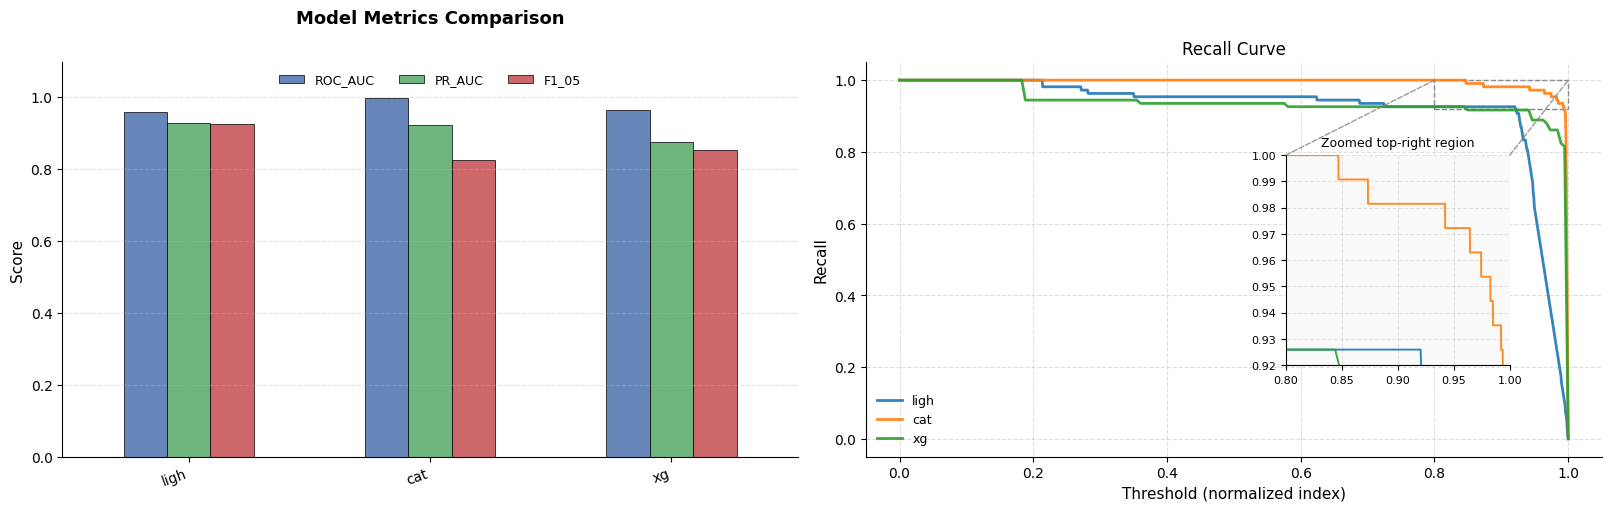

In [25]:
# Base config
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

models = val_df["model"].values
metrics = ["roc_auc", "pr_auc", "f1_05"]
 
# LEFT — Metrics Barplot
ax1 = axes[0]

x = np.arange(len(models))
width = 0.18

colors = {
    "roc_auc": "#4C72B0",
    "pr_auc": "#55A868",
    "f1_05": "#C44E52",
}

for i, metric in enumerate(metrics):
    ax1.bar(
        x + (i - 1) * width,
        val_df[metric].values,
        width=width,
        label=metric.upper(),
        linewidth=0.6,
        edgecolor="black",
        alpha=0.85,
        color=colors.get(metric),
    )

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20, ha="right", fontsize=10)

ax1.margins(x=0.1)

ax1.set_title(
    "Model Metrics Comparison",
    pad=28,
    fontsize=13,
    fontweight="bold"
)

y_min, y_max = ax1.get_ylim()
ax1.set_ylim(0, y_max + 0.05)

ax1.set_ylabel("Score")
ax1.legend(frameon=False, ncol=3, loc="upper center")
ax1.grid(axis="y", linestyle="--", alpha=0.4)


# RIGHT — Recall Curve
ax2 = axes[1]

for _, row in val_df.iterrows():
    recall_curve = np.array(row["recall_curve"])
    x_vals = np.linspace(0, 1, len(recall_curve))
    ax2.plot(
        x_vals,
        recall_curve,
        label=row["model"],
        linewidth=2,
        alpha=0.9,
    )

ax2.set_xlabel("Threshold (normalized index)")
ax2.set_ylabel("Recall")
ax2.set_title("Recall Curve")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(frameon=False, loc="lower left")

x1_min, x1_max = 0.8, 1.0
y1_min, y1_max = 0.92, 1.00

zoom_rect = Rectangle(
    (x1_min, y1_min),
    x1_max - x1_min,
    y1_max - y1_min,
    linewidth=1,
    edgecolor="gray",
    linestyle="--",
    facecolor="none",
)
ax2.add_patch(zoom_rect)


# OUTSIDE-INSET
zoom_ax = fig.add_axes([0.80, 0.28, 0.14, 0.42])
zoom_ax.set_facecolor("#f9f9f9")

for _, row in val_df.iterrows():
    recall_curve = np.array(row["recall_curve"])
    x_vals = np.linspace(0, 1, len(recall_curve))
    zoom_ax.plot(
        x_vals,
        recall_curve,
        linewidth=1.4,
        alpha=0.9,
    )

zoom_ax.set_xlim(x1_min, x1_max)
zoom_ax.set_ylim(y1_min, y1_max)
zoom_ax.grid(True, linestyle="--", alpha=0.3)
zoom_ax.set_title("Zoomed top-right region", fontsize=9)
zoom_ax.tick_params(labelsize=8)


# CONNECTOR LINES
corners_main = [
    (x1_min, y1_max),
    (x1_max, y1_max),
]

corners_zoom = [
    (x1_min, y1_max),
    (x1_max, y1_max),
]

for (xm, ym), (xz, yz) in zip(corners_main, corners_zoom):
    con = ConnectionPatch(
        xyA=(xz, yz), coordsA=zoom_ax.transData,
        xyB=(xm, ym), coordsB=ax2.transData,
        arrowstyle="-",
        linestyle="--",
        color="gray",
        linewidth=1,
        alpha=0.8,
    )
    fig.add_artist(con)

plt.show()

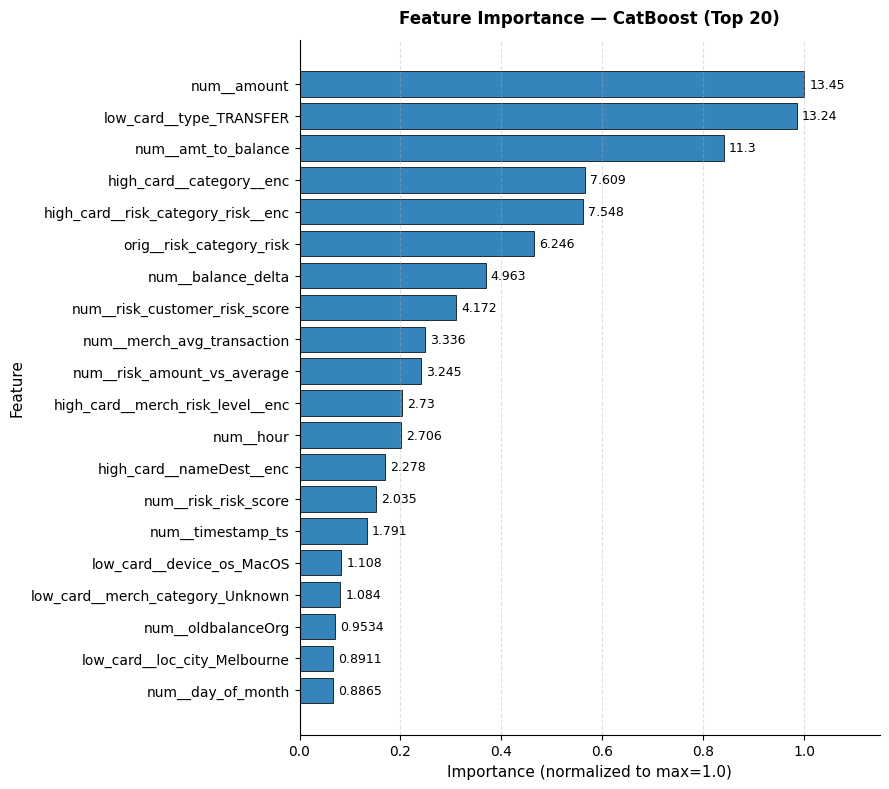

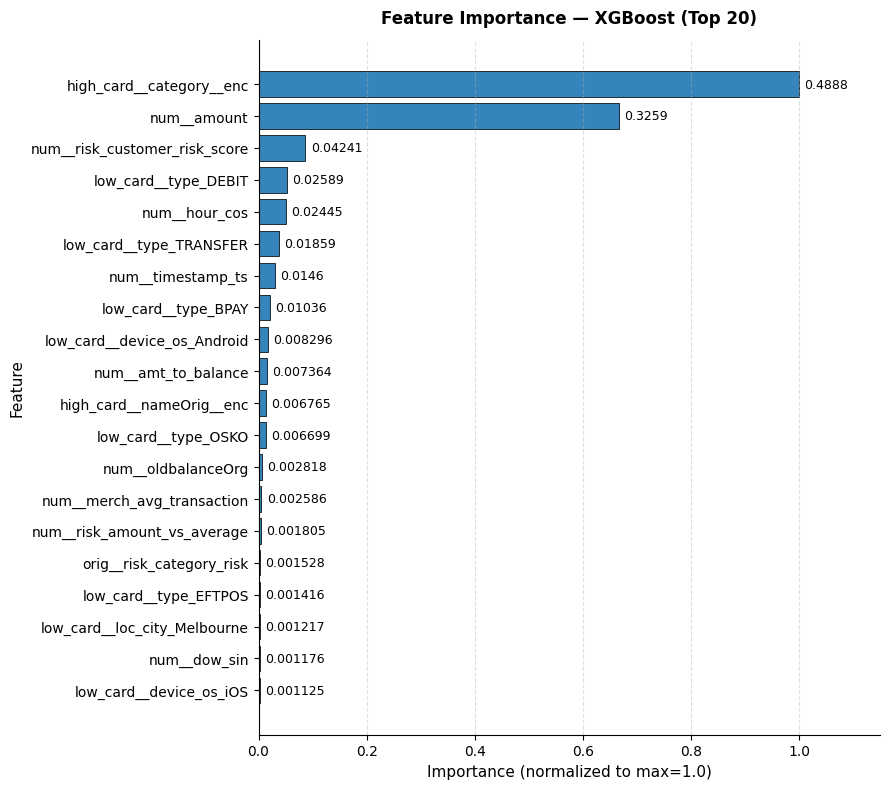

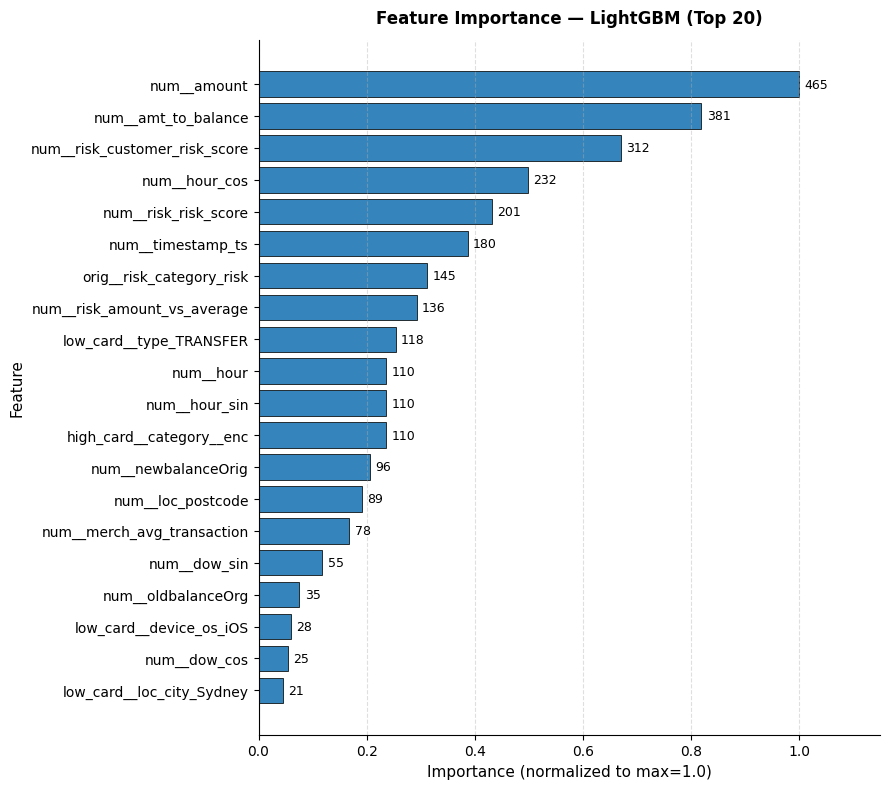

In [26]:
plot_feature_importance(feature_importances["cat"], "CatBoost", top_n=20)
plot_feature_importance(feature_importances["xg"], "XGBoost", top_n=20)
plot_feature_importance(feature_importances["ligh"], "LightGBM", top_n=20)

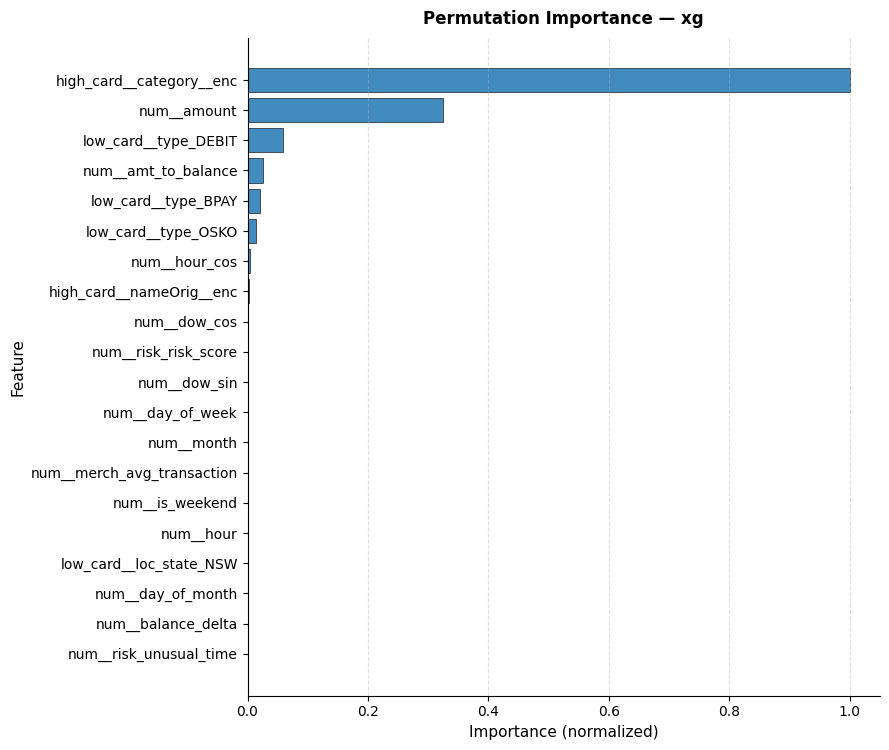

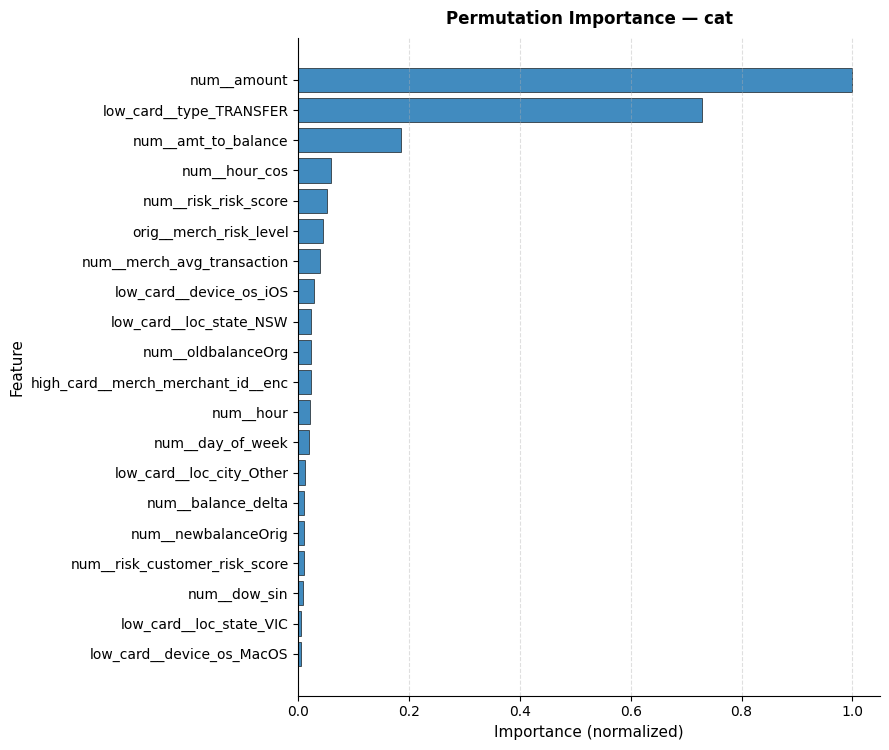

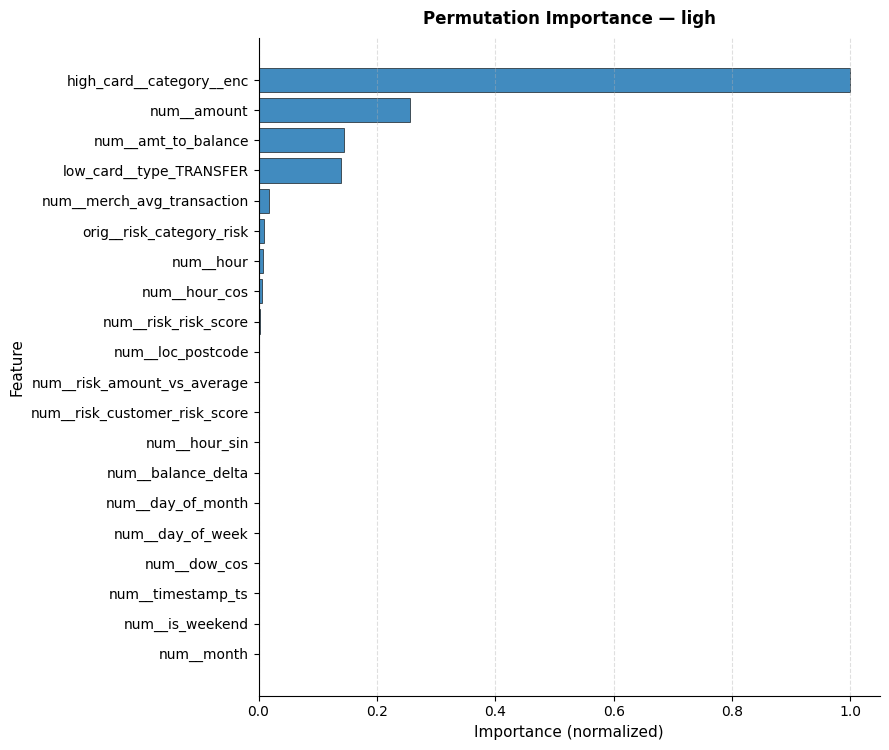

In [27]:
plot_permutation_importance_all(fi_perm, top_n=20)

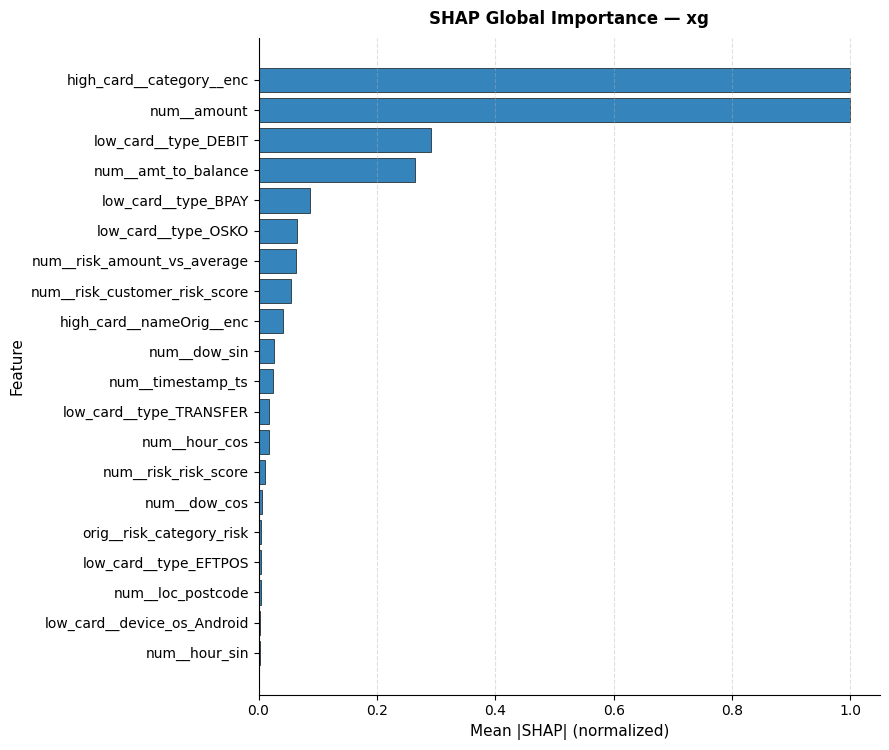

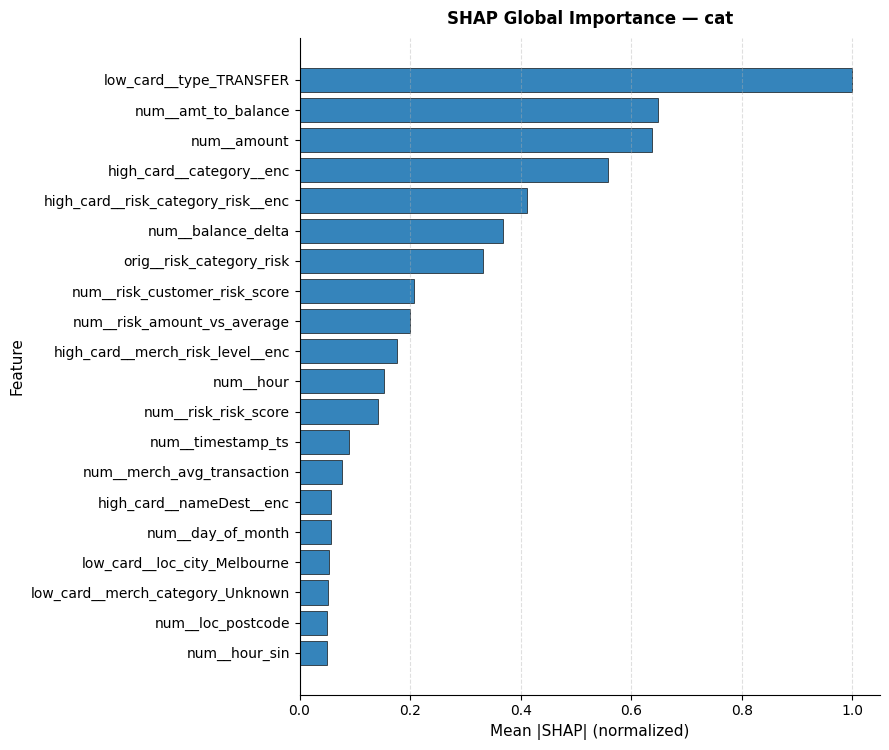

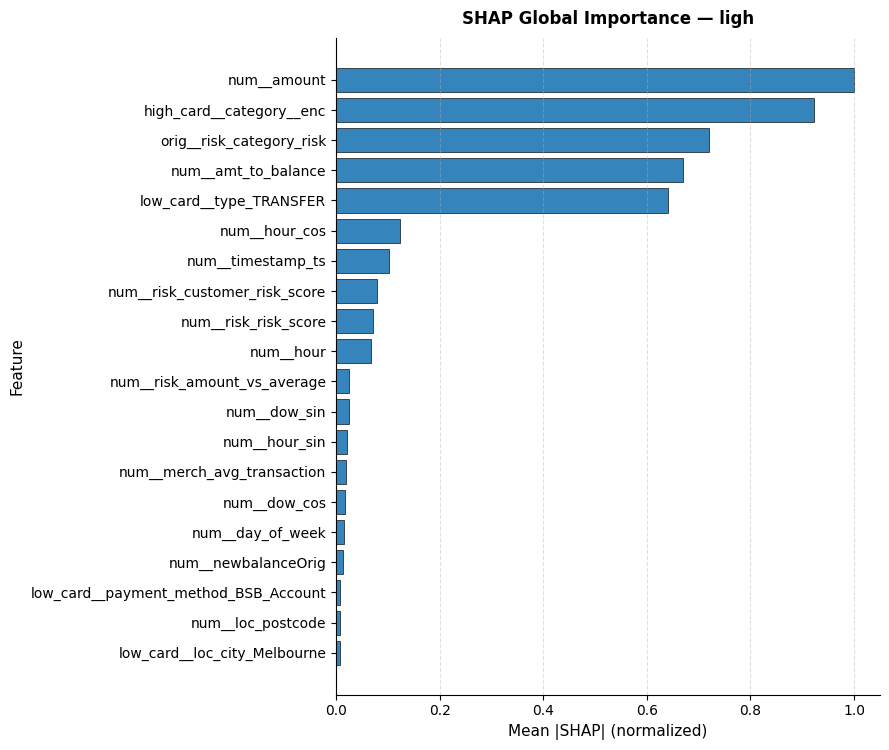

In [28]:
plot_shap_global_importance_all(shap_df, top_n=20)

## Fine tuning + stacking

In [22]:
N_TRIALS = 50
META_SPLITS = 5
RANDOM_STATE = 42

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [23]:
def pr_auc_score(y_true, proba):
    return average_precision_score(y_true, proba)

def evaluate_binary(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred, zero_division=0),
    }

def best_f1_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    if len(thresholds) == 0:
        return 0.5

    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = np.nanargmax(f1)
    return float(thresholds[best_idx])

In [ ]:
def build_model(name, params, scale_pos_weight, early_stopping_rounds=50):
    if name == "xgb":
        return XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            early_stopping_rounds=early_stopping_rounds,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )

    if name == "lgbm":
        return LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

    if name == "cat":
        return CatBoostClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="PRAUC",
            early_stopping_rounds=early_stopping_rounds,
            random_state=RANDOM_STATE,
            has_time=True,
            verbose=False,
            allow_writing_files=False,
        )

    raise ValueError(f"Unknown model: {name}")

def fit_model(name, model, X_tr, y_tr, X_va, y_va):
    if name == "xgb":
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        return model

    if name == "lgbm":
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
        return model

    if name == "cat":
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va))
        return model

    raise ValueError(f"Unknown model: {name}")

In [ ]:
def suggest_params(trial, name):
    if name == "xgb":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 2000, step=100),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        }

    if name == "lgbm":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 2000, step=100),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 20, 300),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }

    if name == "cat":
        return {
            "iterations": trial.suggest_int("iterations", 300, 2000, step=100),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
            "border_count": trial.suggest_int("border_count", 32, 255),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        }

    raise ValueError(f"Unknown model: {name}")

def make_objective(name):
    def objective(trial):
        params = suggest_params(trial, name)
        model = build_model(
            name=name,
            params=params,
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=50,
        )
        model = fit_model(name, model, X_train, y_train, X_val, y_val)
        val_proba = model.predict_proba(X_val)[:, 1]
        return pr_auc_score(y_val, val_proba)
    return objective

def tune_model(name, n_trials=N_TRIALS):
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
        study_name=f"{name}_study",
    )
    study.optimize(make_objective(name), n_trials=n_trials, show_progress_bar=True)
    return study

In [ ]:
studies = {}
best_params = {}

for name in ["xgb", "lgbm", "cat"]:
    print(f"Tuning {name} ...")
    study = tune_model(name, n_trials=N_TRIALS)
    studies[name] = study
    best_params[name] = study.best_params
    print(f"{name} best PR-AUC on val: {study.best_value:.6f}")
    print(best_params[name])
    print("-" * 60)

In [ ]:
base_models_train = {}

for name in ["xgb", "lgbm", "cat"]:
    model = build_model(
        name=name,
        params=best_params[name],
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
    )
    model = fit_model(name, model, X_train, y_train, X_val, y_val)
    base_models_train[name] = model

In [ ]:
def make_oof_meta_features(X, y, best_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    model_names = ["xgb", "lgbm", "cat"]

    oof = np.full((len(X), len(model_names)), np.nan, dtype=np.float64)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X), 1):
        print(f"OOF fold {fold}/{n_splits} | train={len(tr_idx):,} val={len(va_idx):,}")

        X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
        X_va, y_va = X.iloc[va_idx], y[va_idx]

        for col_idx, name in enumerate(model_names):
            fold_model = build_model(
                name=name,
                params=best_params[name],
                scale_pos_weight=scale_pos_weight,
                early_stopping_rounds=30,
            )
            fold_model = fit_model(name, fold_model, X_tr, y_tr, X_va, y_va)
            oof[va_idx, col_idx] = fold_model.predict_proba(X_va)[:, 1]

    valid_mask = ~np.isnan(oof).any(axis=1)
    oof_df = pd.DataFrame(
        oof[valid_mask],
        columns=["xgb_prob", "lgbm_prob", "cat_prob"],
    )
    y_oof = y[valid_mask]
    return oof_df, y_oof

oof_meta_df, y_oof = make_oof_meta_features(
    X_train.reset_index(drop=True),
    y_train,
    best_params=best_params,
    n_splits=META_SPLITS,
)

print("OOF meta shape:", oof_meta_df.shape)

In [ ]:
meta_learner = SkPipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

meta_learner.fit(oof_meta_df, y_oof)

print(
    "Meta coefficients:",
    meta_learner.named_steps["lr"].coef_[0].round(4)
)

In [ ]:
val_meta_df = pd.DataFrame({
    "xgb_prob": base_models_train["xgb"].predict_proba(X_val)[:, 1],
    "lgbm_prob": base_models_train["lgbm"].predict_proba(X_val)[:, 1],
    "cat_prob": base_models_train["cat"].predict_proba(X_val)[:, 1],
})

val_stack_proba = meta_learner.predict_proba(val_meta_df)[:, 1]
best_stack_threshold = best_f1_threshold(y_val, val_stack_proba)

print(f"Best stack threshold from val: {best_stack_threshold:.6f}")

In [ ]:
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = np.concatenate([y_train, y_val])

base_models_trainval = {}

for name in ["xgb", "lgbm", "cat"]:
    params = best_params[name].copy()

    if name == "xgb":
        model = XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
        model.fit(X_trainval, y_trainval, verbose=False)

    elif name == "lgbm":
        model = LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(X_trainval, y_trainval)

    elif name == "cat":
        model = CatBoostClassifier(
            **params,
            scale_pos_weight=scale_pos_weight,
            eval_metric="PRAUC",
            random_state=RANDOM_STATE,
            has_time=True,
            verbose=False,
            allow_writing_files=False,
        )
        model.fit(X_trainval, y_trainval)

    base_models_trainval[name] = model

test_meta_df = pd.DataFrame({
    "xgb_prob": base_models_trainval["xgb"].predict_proba(X_test)[:, 1],
    "lgbm_prob": base_models_trainval["lgbm"].predict_proba(X_test)[:, 1],
    "cat_prob": base_models_trainval["cat"].predict_proba(X_test)[:, 1],
})

stack_test_proba = meta_learner.predict_proba(test_meta_df)[:, 1]

results = []
for name in ["xgb", "lgbm", "cat"]:
    proba = base_models_trainval[name].predict_proba(X_test)[:, 1]
    m = evaluate_binary(y_test, proba, threshold=0.5)
    results.append({
        "model": f"{name}_tuned",
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
        "f1_05": m["f1"],
    })

stack_metrics = evaluate_binary(y_test, stack_test_proba, threshold=best_stack_threshold)
results.append({
    "model": "stacking_lr_clean",
    "roc_auc": stack_metrics["roc_auc"],
    "pr_auc": stack_metrics["pr_auc"],
    "f1_05": stack_metrics["f1"],
})

results_df = (
    pd.DataFrame(results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

results_df.style.highlight_max(subset=["roc_auc", "pr_auc", "f1_05"], color="green").highlight_min(subset=["roc_auc", "pr_auc", "f1_05"], color="red")

## Using build_models

In [ ]:
ensemble = AMLEnsemble(
    n_trials=50,
    meta_splits=5,
    random_state=42,
)
ensemble.fit(X_train, y_train, X_val, y_val)

test_metrics = ensemble.evaluate(X_test, y_test)
print(test_metrics)

esults_df = ensemble.evaluate_base_models(X_test, y_test)
esults_df.style.highlight_max(subset=["roc_auc", "pr_auc", "f1_05"], color="green").highlight_min(subset=["roc_auc", "pr_auc", "f1_05"], color="red")